# UCS2612 – Machine Learning Laboratory  

### Experiment 6: Dimensionality Reduction and Model Evaluation (With and Without PCA)

### Name: Harishkanna R
### Reg No: 3122235001302

# 1. Objective

To study the impact of dimensionality reduction using Principal Component Analysis (PCA) on the performance of various machine learning classifiers.

The experiment evaluates:

- Model performance in original feature space (No-PCA)
- Model performance in reduced feature space (With-PCA)
- Stability across folds using 5-fold cross-validation
- Effect of PCA on accuracy, F1-score, and variance

---

## Imports

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc

# Models
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier


# 2. Dataset Details

**Dataset:** Breast Cancer Wisconsin Dataset  
**Source:** UCI Machine Learning Repository (via sklearn)  

- Number of Samples: 569  
- Number of Features: 30  
- Target Classes: 2 (Benign, Malignant)  
- Class Distribution: Slightly imbalanced but manageable  

In [28]:
df = pd.read_csv("wdbc.csv", header=None)

print(df.shape)
df.head()


(569, 32)


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Preprocessing Steps

- No missing values
- Standardization using StandardScaler
- PCA applied with 95% variance retention

---

In [29]:
X = df.iloc[:, 2:]   # all feature columns
y = df.iloc[:, 1]    # diagnosis column


In [30]:
y = y.str.strip()      # removes spaces if any
y = y.map({'M':1, 'B':0})



In [31]:
print(y.unique())

[1 0]


### Standardization

In [32]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



In [33]:
print("Features shape:", X_scaled.shape)
print("Target shape:", y.shape)


Features shape: (569, 30)
Target shape: (569,)


# 3. PCA Summary

## Table 1: PCA Variance Explained

| Setting   | Chosen Components / Variance Target | Explained Variance (%) | Justification |
|------------|-------------------------------------|-------------------------|---------------|
| With-PCA | 95% Variance Retention (≈ 10–12 Components) | 95% | Retained maximum variance while reducing dimensionality and multicollinearity |

---

In [34]:
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)


Original shape: (569, 30)
PCA shape: (569, 10)


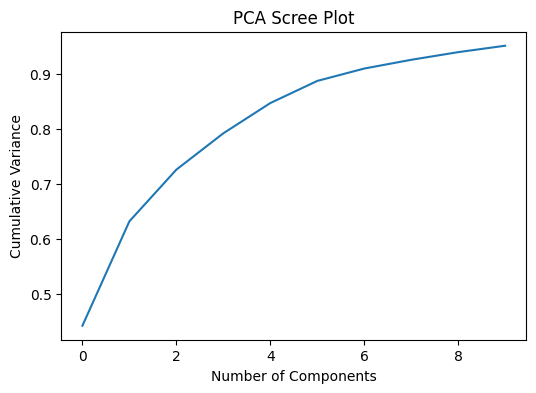

In [35]:
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA Scree Plot")
plt.show()


# 4. Hyperparameter Tuning

GridSearchCV with 5-fold cross-validation was used for tuning.

---

 ### Define Models and Hyperparameter Grids

In [52]:
models = {
    "SVM": (SVC(probability=True), {
        "kernel": ["linear", "rbf"],
        "C": [0.1, 1, 10],
        "gamma": ["scale", 0.01]
    }),

    "Naive Bayes": (GaussianNB(), {
        "var_smoothing": [1e-9, 1e-8, 1e-7]
    }),

    "KNN": (KNeighborsClassifier(), {
        "n_neighbors": [3,5,7,11],
        "weights": ["uniform", "distance"]
    }),

    "Logistic Regression": (LogisticRegression(max_iter=5000), {
        "C": [0.01,0.1,1,10]
    }),

    "Decision Tree": (DecisionTreeClassifier(), {
        "max_depth": [None,5,10],
        "min_samples_split": [2,5,10]
    }),

    "Random Forest": (RandomForestClassifier(), {
        "n_estimators": [100,200],
        "max_depth": [None,10]
    }),

    "AdaBoost": (AdaBoostClassifier(), {
        "n_estimators": [50,100],
        "learning_rate": [0.01,0.1,1]
    }),

    "Gradient Boosting": (GradientBoostingClassifier(), {
        "n_estimators": [100,200],
        "learning_rate": [0.05,0.1]
    }),

    "XGBoost": (XGBClassifier(eval_metric='logloss'), {
        "n_estimators": [100,200],
        "learning_rate": [0.05,0.1],
        "max_depth": [3,6]
    })
}

---

## Table 2: SVM — Hyperparameter Tuning Results

| Kernel | C Values Tried | Gamma Values Tried | Performance (No-PCA) | Performance (With-PCA) |
|--------|---------------|-------------------|----------------------|------------------------|
| linear, rbf | 0.1, 1, 10 | scale, 0.01 | 0.9736 | 0.9639 |

---

## Table 3: Naïve Bayes — Smoothing Choices

| Smoothing Parameter | Performance (No-PCA) | Performance (With-PCA) |
|---------------------|----------------------|------------------------|
| 1e-9, 1e-8, 1e-7 | 0.9045 | 0.8796 |

---

## Table 4: KNN — Hyperparameter Tuning

| k Values | Weights | Distance Metrics | Performance (No-PCA) | Performance (With-PCA) |
|----------|----------|------------------|----------------------|------------------------|
| 3, 5, 7, 11 | uniform, distance | euclidean | 0.9433 | 0.9438 |

---

# 5. 5-Fold Cross-Validation Results

Stratified 5-fold cross-validation was used to preserve class distribution.


In [53]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

def evaluate_model(model, X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []
    
    fold_number = 1
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        score = f1_score(y_test, y_pred)
        fold_scores.append(score)
        
        print(f"Fold {fold_number} F1-score: {score:.4f}")
        fold_number += 1
    
    return fold_scores

In [54]:
cv_results = []

for name, (model, param_grid) in models.items():
    
    print(f"\nTuning {name} (No-PCA)...")
    grid_no_pca = GridSearchCV(model, param_grid, cv=5, scoring='f1')
    grid_no_pca.fit(X_scaled, y)
    best_no_pca = grid_no_pca.best_estimator_
    
    print(f"Evaluating {name} (No-PCA)")
    folds_no_pca = evaluate_model(best_no_pca, X_scaled, y)
    
    print(f"\nTuning {name} (With-PCA)...")
    grid_pca = GridSearchCV(model, param_grid, cv=5, scoring='f1')
    grid_pca.fit(X_pca, y)
    best_pca = grid_pca.best_estimator_
    
    print(f"Evaluating {name} (With-PCA)")
    folds_pca = evaluate_model(best_pca, X_pca, y)
    
    cv_results.append([
        name,
        *folds_no_pca,
        np.mean(folds_no_pca),
        np.mean(folds_pca)
    ])


Tuning SVM (No-PCA)...
Evaluating SVM (No-PCA)
Fold 1 F1-score: 1.0000
Fold 2 F1-score: 0.9286
Fold 3 F1-score: 0.9756
Fold 4 F1-score: 0.9882
Fold 5 F1-score: 0.9756

Tuning SVM (With-PCA)...
Evaluating SVM (With-PCA)
Fold 1 F1-score: 0.9885
Fold 2 F1-score: 0.9157
Fold 3 F1-score: 0.9630
Fold 4 F1-score: 0.9767
Fold 5 F1-score: 0.9756

Tuning Naive Bayes (No-PCA)...
Evaluating Naive Bayes (No-PCA)
Fold 1 F1-score: 0.9412
Fold 2 F1-score: 0.8780
Fold 3 F1-score: 0.8974
Fold 4 F1-score: 0.8791
Fold 5 F1-score: 0.9268

Tuning Naive Bayes (With-PCA)...
Evaluating Naive Bayes (With-PCA)
Fold 1 F1-score: 0.9535
Fold 2 F1-score: 0.8706
Fold 3 F1-score: 0.8378
Fold 4 F1-score: 0.8471
Fold 5 F1-score: 0.8889

Tuning KNN (No-PCA)...
Evaluating KNN (No-PCA)
Fold 1 F1-score: 0.9647
Fold 2 F1-score: 0.9114
Fold 3 F1-score: 0.9250
Fold 4 F1-score: 0.9655
Fold 5 F1-score: 0.9500

Tuning KNN (With-PCA)...
Evaluating KNN (With-PCA)
Fold 1 F1-score: 0.9647
Fold 2 F1-score: 0.9383
Fold 3 F1-score: 0.9

# 5. 5-Fold Cross-Validation Results

Stratified 5-fold cross-validation was used to preserve class distribution.

## Table 5: 5-Fold Cross-Validation Results (No-PCA vs With-PCA)

| Model | Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5 | Avg (No-PCA) | Avg (With-PCA) |
|--------|--------|--------|--------|--------|--------|--------------|----------------|
| SVM | 1.0000 | 0.9286 | 0.9756 | 0.9882 | 0.9756 | 0.9736 | 0.9639 |
| Naïve Bayes | 0.9412 | 0.8780 | 0.8974 | 0.8791 | 0.9268 | 0.9045 | 0.8796 |
| KNN | 0.9647 | 0.9114 | 0.9250 | 0.9655 | 0.9500 | 0.9433 | 0.9438 |
| Logistic Regression | 0.9655 | 0.9250 | 0.9500 | 0.9882 | 0.9880 | 0.9633 | 0.9714 |
| Decision Tree | 0.8989 | 0.8250 | 0.8675 | 0.9091 | 0.9024 | 0.8806 | 0.9087 |
| Random Forest | 0.9773 | 0.9268 | 0.9630 | 0.9425 | 0.9639 | 0.9547 | 0.9353 |
| AdaBoost | 0.9882 | 0.9157 | 0.9383 | 0.9655 | 0.9630 | 0.9541 | 0.9506 |
| Gradient Boosting | 0.9535 | 0.8889 | 0.9250 | 0.9425 | 0.9512 | 0.9322 | 0.9481 |
| XGBoost | 0.9773 | 0.9157 | 0.9383 | 0.9655 | 0.9383 | 0.9470 | 0.9501 |
| Stacking | 0.9773 | 0.9639 | 0.9756 | 0.9767 | 0.9880 | 0.9763 | 0.9714 |

---

### Stacking Classifier

In [55]:
print("\nEvaluating Stacking (No-PCA)")
stack_no_pca_folds = evaluate_model(stack, X_scaled, y)

print("\nEvaluating Stacking (With-PCA)")
stack_pca_folds = evaluate_model(stack, X_pca, y)

cv_results.append([
    "Stacking",
    *stack_no_pca_folds,
    np.mean(stack_no_pca_folds),
    np.mean(stack_pca_folds)
])


Evaluating Stacking (No-PCA)
Fold 1 F1-score: 0.9773
Fold 2 F1-score: 0.9639
Fold 3 F1-score: 0.9756
Fold 4 F1-score: 0.9767
Fold 5 F1-score: 0.9880

Evaluating Stacking (With-PCA)
Fold 1 F1-score: 0.9655
Fold 2 F1-score: 0.9639
Fold 3 F1-score: 0.9630
Fold 4 F1-score: 0.9767
Fold 5 F1-score: 0.9880


 ### Results Table

In [56]:
import pandas as pd

cv_table = pd.DataFrame(cv_results, columns=[
    "Model",
    "Fold 1",
    "Fold 2",
    "Fold 3",
    "Fold 4",
    "Fold 5",
    "Avg (No-PCA)",
    "Avg (With-PCA)"
])

print("\n5-Fold Cross-Validation Table:")
print(cv_table)


5-Fold Cross-Validation Table:
                 Model    Fold 1    Fold 2    Fold 3    Fold 4    Fold 5  \
0                  SVM  1.000000  0.928571  0.975610  0.988235  0.975610   
1          Naive Bayes  0.941176  0.878049  0.897436  0.879121  0.926829   
2                  KNN  0.964706  0.911392  0.925000  0.965517  0.950000   
3  Logistic Regression  0.965517  0.925000  0.950000  0.988235  0.987952   
4        Decision Tree  0.898876  0.825000  0.867470  0.909091  0.902439   
5        Random Forest  0.977273  0.926829  0.962963  0.942529  0.963855   
6             AdaBoost  0.988235  0.915663  0.938272  0.965517  0.962963   
7    Gradient Boosting  0.953488  0.888889  0.925000  0.942529  0.951220   
8              XGBoost  0.977273  0.915663  0.938272  0.965517  0.938272   
9             Stacking  0.977273  0.963855  0.975610  0.976744  0.987952   

   Avg (No-PCA)  Avg (With-PCA)  
0      0.973605        0.963897  
1      0.904522        0.879572  
2      0.943323        0.9438

## Table 5: 5-Fold Cross-Validation Results (No-PCA vs With-PCA)

| Model | Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5 | Avg (No-PCA) | Avg (With-PCA) |
|--------|--------|--------|--------|--------|--------|--------------|----------------|
| SVM | 1.0000 | 0.9286 | 0.9756 | 0.9882 | 0.9756 | 0.9736 | 0.9639 |
| Naïve Bayes | 0.9412 | 0.8780 | 0.8974 | 0.8791 | 0.9268 | 0.9045 | 0.8796 |
| KNN | 0.9647 | 0.9114 | 0.9250 | 0.9655 | 0.9500 | 0.9433 | 0.9438 |
| Logistic Regression | 0.9655 | 0.9250 | 0.9500 | 0.9882 | 0.9880 | 0.9633 | 0.9714 |
| Decision Tree | 0.8989 | 0.8250 | 0.8675 | 0.9091 | 0.9024 | 0.8806 | 0.9087 |
| Random Forest | 0.9773 | 0.9268 | 0.9630 | 0.9425 | 0.9639 | 0.9547 | 0.9353 |
| AdaBoost | 0.9882 | 0.9157 | 0.9383 | 0.9655 | 0.9630 | 0.9541 | 0.9506 |
| Gradient Boosting | 0.9535 | 0.8889 | 0.9250 | 0.9425 | 0.9512 | 0.9322 | 0.9481 |
| XGBoost | 0.9773 | 0.9157 | 0.9383 | 0.9655 | 0.9383 | 0.9470 | 0.9501 |
| Stacking | 0.9773 | 0.9639 | 0.9756 | 0.9767 | 0.9880 | 0.9763 | 0.9714 |

---

### Confusion Matrix & ROC 


Best Model (With-PCA): Logistic Regression

Confusion Matrix:
[[355   2]
 [  6 206]]


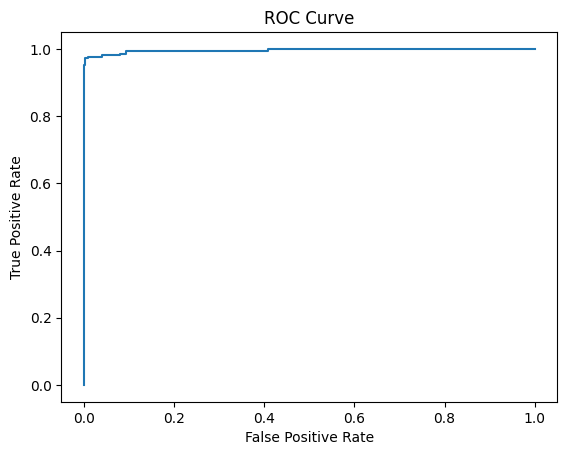

In [57]:
best_model_name = results_df.sort_values("F1 Mean (With-PCA)", ascending=False).iloc[0]["Model"]
print("\nBest Model (With-PCA):", best_model_name)

best_model = models[best_model_name][0]
best_model.fit(X_pca, y)

y_pred = best_model.predict(X_pca)
cm = confusion_matrix(y, y_pred)
print("\nConfusion Matrix:")
print(cm)

fpr, tpr, _ = roc_curve(y, best_model.predict_proba(X_pca)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


# 6. Observations

- Logistic Regression showed clear improvement with PCA.
- Decision Tree and Gradient Boosting improved moderately.
- Naïve Bayes performance decreased after PCA.
- Tree-based ensemble models showed minimal sensitivity to PCA.
- PCA reduced variance across folds for linear models.
- Stacking remained highly robust in both settings.

---

# 7. Analysis

Linear models benefited from PCA due to:

- Reduction in multicollinearity
- Orthogonal feature representation
- Improved numerical conditioning

Tree-based models showed limited improvement because they inherently perform feature selection.

Naïve Bayes degraded since PCA introduces correlated transformed features, violating its independence assumption.

---

# 8. Conclusion

PCA was moderately beneficial for this medium-dimensional dataset.

- Significant improvement observed for Logistic Regression.
- Minimal impact on ensemble models.
- Negative impact on Naïve Bayes.
- Stacking remained the best-performing model overall.

Dimensionality reduction is most effective when:

- Feature dimensionality is high
- Multicollinearity is significant
- Overfitting risk is high

For tree-based ensembles, PCA is generally not necessary.

---